In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:

trd_df =  pd.read_csv("/content/historical_data.csv")
smt_df = pd.read_csv("/content/fear_greed_index.csv")
print("trade data shape:",trd_df.shape)
print("sentiment data shape:",smt_df)
print(trd_df.head())
print(smt_df.head())
print("trade columns",trd_df.columns.tolist())
print("sentiment columns",smt_df.columns.tolist())

trade data shape: (211224, 16)
sentiment data shape:        timestamp  value classification        date
0     1517463000     30           Fear  2018-02-01
1     1517549400     15   Extreme Fear  2018-02-02
2     1517635800     40           Fear  2018-02-03
3     1517722200     24   Extreme Fear  2018-02-04
4     1517808600     11   Extreme Fear  2018-02-05
...          ...    ...            ...         ...
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02

[2644 rows x 4 columns]
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111f

In [7]:
trd_df['time']=pd.to_datetime(trd_df['Timestamp IST'],dayfirst=True)
trd_df['time']=trd_df['time'].dt.date
trd_df['closed PnL'] =pd.to_numeric(trd_df['Closed PnL'],errors='coerce').fillna(0)
trd_df['Size USD']=pd.to_numeric(trd_df['Size USD'],errors='coerce').fillna(0)
print("trrader data cleansed")
print(trd_df[['time','Closed PnL','Size USD']].head())

trrader data cleansed
         time  Closed PnL  Size USD
0  2024-12-02         0.0   7872.16
1  2024-12-02         0.0    127.68
2  2024-12-02         0.0   1150.63
3  2024-12-02         0.0   1142.04
4  2024-12-02         0.0     69.75


In [12]:
smt_df['date']=pd.to_datetime(smt_df['date']).dt.date
print("sentiment clened")
print(smt_df.head())
print(trd_df.isnull().sum())
print(smt_df.isnull().sum())

sentiment clened
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
time                0
closed PnL          0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [15]:
merged_df = pd.merge(trd_df,smt_df[['date','classification']],left_on='time',right_on='date',how='left')
print("merged data")
print("merger shape:",merged_df.head())

merged data
merger shape:                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID 

In [16]:
# See first 5 rows of merged data
print(merged_df[['date', 'Closed PnL', 'Size USD', 'classification']].head(10))

         date  Closed PnL  Size USD classification
0  2024-12-02         0.0   7872.16  Extreme Greed
1  2024-12-02         0.0    127.68  Extreme Greed
2  2024-12-02         0.0   1150.63  Extreme Greed
3  2024-12-02         0.0   1142.04  Extreme Greed
4  2024-12-02         0.0     69.75  Extreme Greed
5  2024-12-02         0.0     11.27  Extreme Greed
6  2024-12-02         0.0   1151.77  Extreme Greed
7  2024-12-02         0.0    272.00  Extreme Greed
8  2024-12-02         0.0    368.00  Extreme Greed
9  2024-12-02         0.0    100.00  Extreme Greed


In [17]:
# Count how many trades have a sentiment label
print("Trades WITH sentiment:", merged_df['classification'].notna().sum())
print("Trades WITHOUT sentiment:", merged_df['classification'].isna().sum())


Trades WITH sentiment: 211218
Trades WITHOUT sentiment: 6


In [18]:
# See all unique sentiment values
print("Sentiment Labels:")
print(merged_df['classification'].value_counts())

Sentiment Labels:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [19]:
# Basic statistics of the full dataset
print("Total Trades:", len(merged_df))
print("Total PnL:", merged_df['Closed PnL'].sum())
print("Average PnL per Trade:", merged_df['Closed PnL'].mean())
print("Overall Win Rate:", (merged_df['Closed PnL'] > 0).mean() * 100, "%")

Total Trades: 211224
Total PnL: 10296958.943436
Average PnL per Trade: 48.74900079269401
Overall Win Rate: 41.12648183918494 %


In [20]:
# Total PnL for each sentiment label
pnl_by_sentiment = merged_df.groupby('classification')['Closed PnL'].sum()
print("Total PnL by Sentiment:")
print(pnl_by_sentiment)

Total PnL by Sentiment:
classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


In [21]:
# Win rate for each sentiment
winrate_by_sentiment = merged_df.groupby('classification')['Closed PnL'].apply(
    lambda x: (x > 0).mean() * 100
)
print("Win Rate by Sentiment:")
print(winrate_by_sentiment)

Win Rate by Sentiment:
classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Closed PnL, dtype: float64


In [22]:
# How many trades happened in each sentiment
trade_count = merged_df.groupby('classification')['Closed PnL'].count()
print("Trade Count by Sentiment:")
print(trade_count)

Trade Count by Sentiment:
classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
Name: Closed PnL, dtype: int64


In [23]:
# Combine everything into one clean summary table
summary = merged_df.groupby('classification').agg(
    Total_PnL    = ('Closed PnL', 'sum'),
    Avg_PnL      = ('Closed PnL', 'mean'),
    Trade_Count  = ('Closed PnL', 'count'),
    Win_Rate     = ('Closed PnL', lambda x: round((x > 0).mean() * 100, 2)),
    Total_Volume = ('Size USD', 'sum')
)

print(" Full Summary Table:")
print(summary)

 Full Summary Table:
                   Total_PnL    Avg_PnL  Trade_Count  Win_Rate  Total_Volume
classification                                                              
Extreme Fear    7.391102e+05  34.537862        21400     37.06  1.144843e+08
Extreme Greed   2.715171e+06  67.892861        39992     46.49  1.244652e+08
Fear            3.357155e+06  54.290400        61837     42.08  4.833248e+08
Greed           2.150129e+06  42.743559        50303     38.48  2.885825e+08
Neutral         1.292921e+06  34.307718        37686     39.70  1.802421e+08


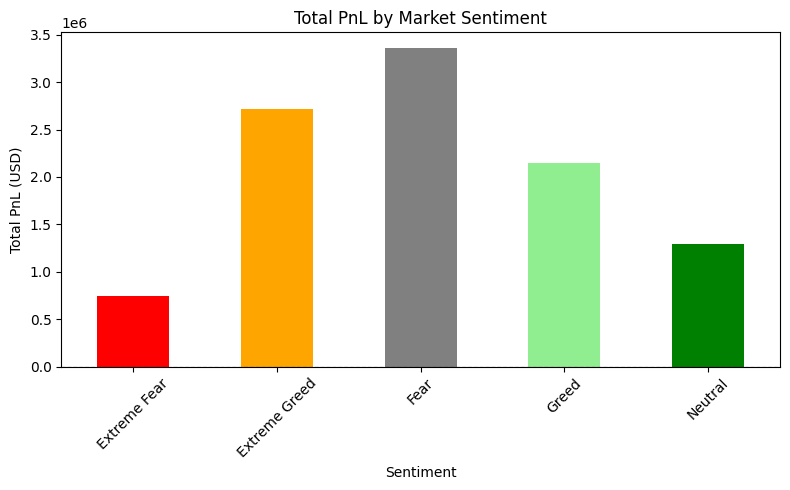

In [24]:
plt.figure(figsize=(8,5))
pnl_by_sentiment.plot(kind='bar', color=['red','orange','grey','lightgreen','green'])
plt.title('Total PnL by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Total PnL (USD)')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

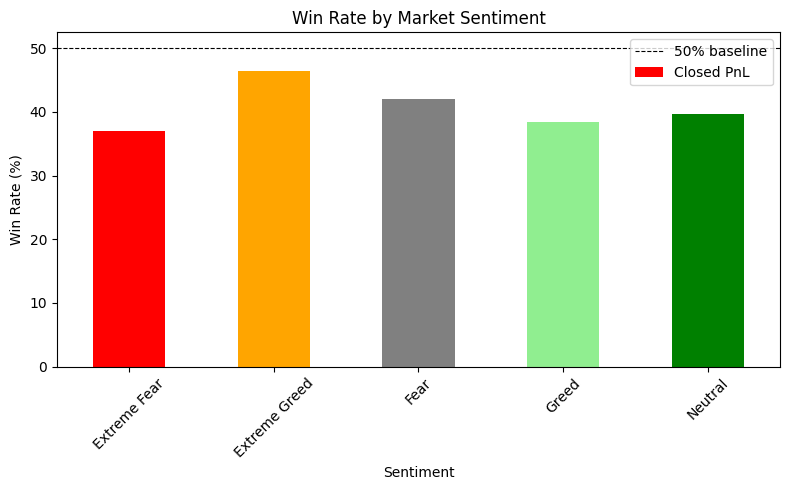

In [25]:
plt.figure(figsize=(8,5))
winrate_by_sentiment.plot(kind='bar', color=['red','orange','grey','lightgreen','green'])
plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45)
plt.axhline(50, color='black', linewidth=0.8, linestyle='--', label='50% baseline')
plt.legend()
plt.tight_layout()
plt.show()

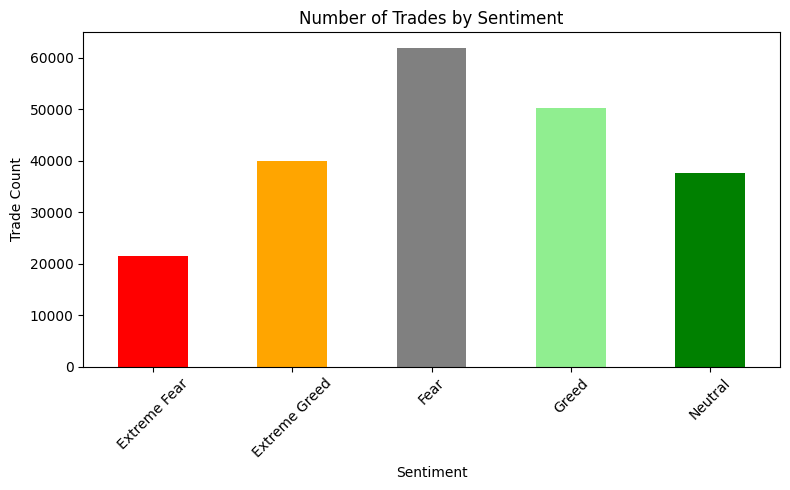

In [26]:
plt.figure(figsize=(8,5))
trade_count.plot(kind='bar', color=['red','orange','grey','lightgreen','green'])
plt.title('Number of Trades by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Trade Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

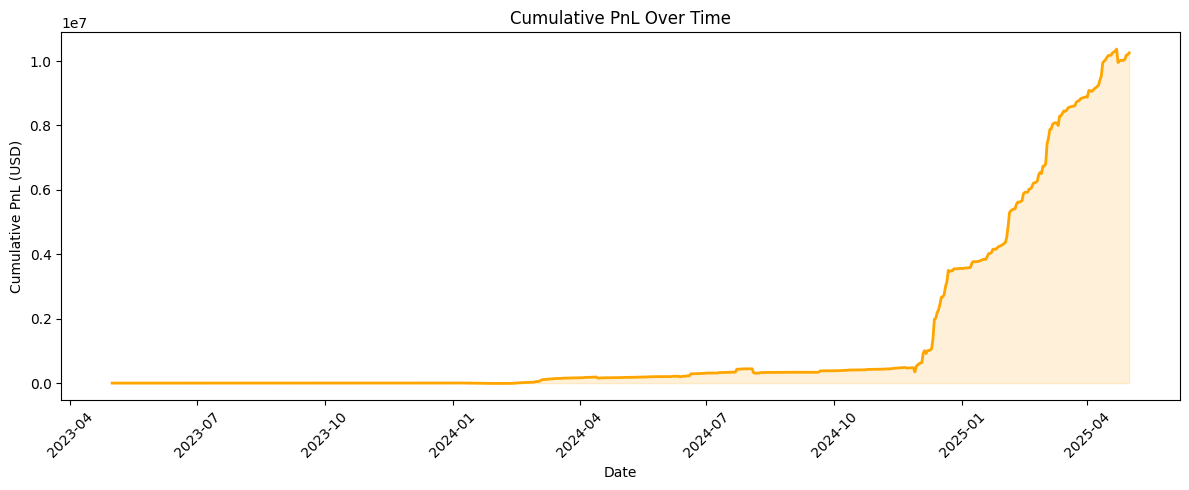

In [27]:
# Sort by date first
daily_pnl = merged_df.groupby('date')['Closed PnL'].sum().reset_index()
daily_pnl = daily_pnl.sort_values('date')
daily_pnl['Cumulative PnL'] = daily_pnl['Closed PnL'].cumsum()

plt.figure(figsize=(12,5))
plt.plot(daily_pnl['date'], daily_pnl['Cumulative PnL'], color='orange', linewidth=2)
plt.fill_between(daily_pnl['date'], daily_pnl['Cumulative PnL'], alpha=0.15, color='orange')
plt.title('Cumulative PnL Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

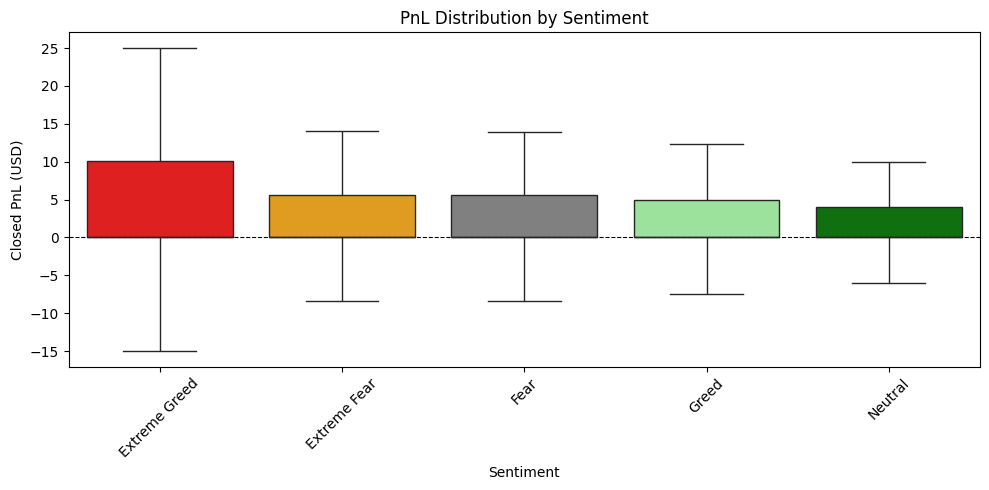

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=merged_df,
    x='classification',
    y='Closed PnL',
    palette=['red','orange','grey','lightgreen','green'],
    showfliers=False   # hides extreme outliers for cleaner view
)
plt.title('PnL Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Closed PnL (USD)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# Create pivot table - Coin vs Sentiment with Total PnL
heatmap_data = merged_df.groupby(
    ['Coin', 'classification']
)['Closed PnL'].sum().unstack()

print(heatmap_data.head())

classification   Extreme Fear  Extreme Greed          Fear          Greed  \
Coin                                                                        
@1                        NaN   4.956676e+02      0.000000       1.078679   
@10                 -0.063484            NaN      0.000000       0.000000   
@100                      NaN   2.762714e+01           NaN            NaN   
@103                      NaN   3.406334e+01           NaN       4.494691   
@107           -136085.368300   1.988619e+06 -12514.843274  724342.305860   

classification        Neutral  
Coin                           
@1                        NaN  
@10                       NaN  
@100                      NaN  
@103                      NaN  
@107            219551.950858  


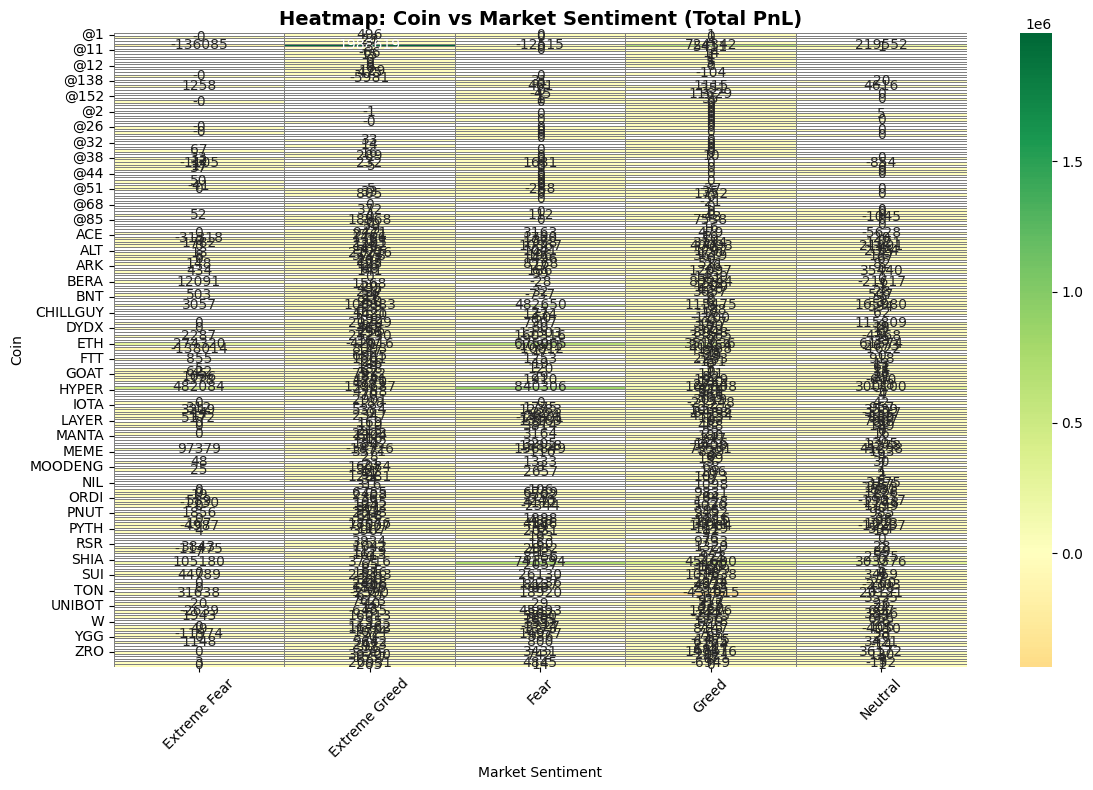

In [30]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap='RdYlGn',        # Red = loss, Yellow = neutral, Green = profit
    center=0,             # Center color at 0
    annot=True,           # Show numbers inside boxes
    fmt='.0f',            # No decimal places
    linewidths=0.5,       # Lines between boxes
    linecolor='grey'
)
plt.title('Heatmap: Coin vs Market Sentiment (Total PnL)', fontsize=14, fontweight='bold')
plt.xlabel('Market Sentiment')
plt.ylabel('Coin')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

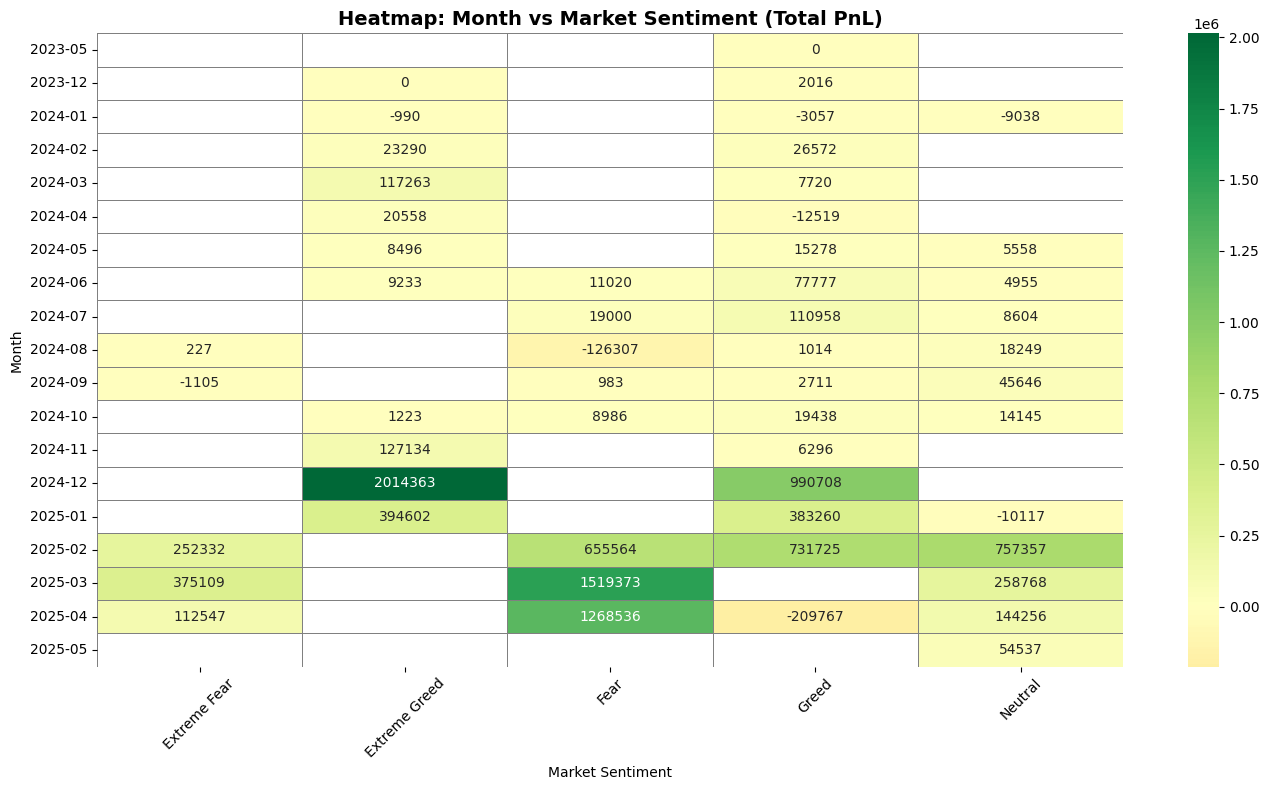

In [31]:
# Extract month from date
merged_df['month'] = pd.to_datetime(merged_df['date']).dt.strftime('%Y-%m')

# Pivot table - Month vs Sentiment
heatmap_month = merged_df.groupby(
    ['month', 'classification']
)['Closed PnL'].sum().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_month,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    linecolor='grey'
)
plt.title('Heatmap: Month vs Market Sentiment (Total PnL)', fontsize=14, fontweight='bold')
plt.xlabel('Market Sentiment')
plt.ylabel('Month')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

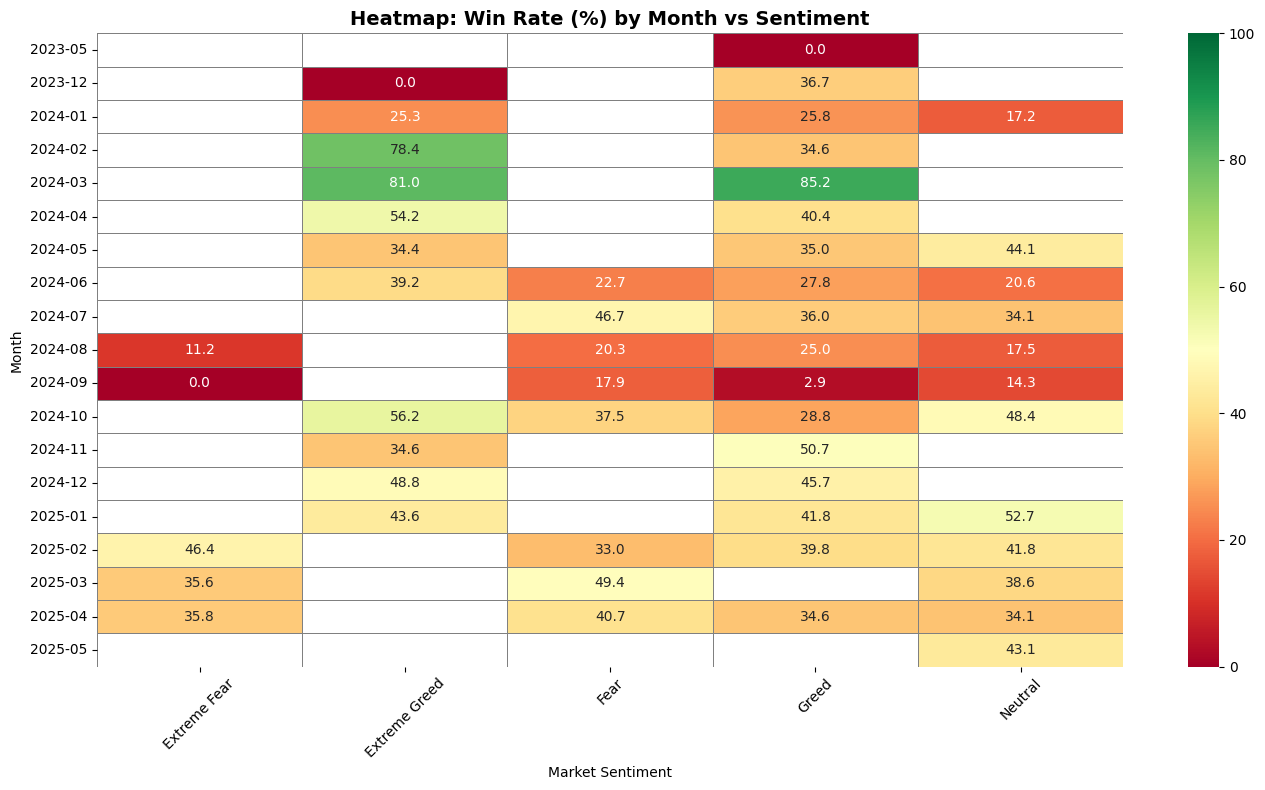

In [32]:
# Win rate pivot
heatmap_winrate = merged_df.groupby(
    ['month', 'classification']
)['Closed PnL'].apply(
    lambda x: round((x > 0).mean() * 100, 1)
).unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_winrate,
    cmap='RdYlGn',
    center=50,             # Center color at 50%
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor='grey',
    vmin=0,
    vmax=100
)
plt.title('Heatmap: Win Rate (%) by Month vs Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Market Sentiment')
plt.ylabel('Month')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
# Which sentiment had highest win rate
best_winrate = summary['Win_Rate'].idxmax()
worst_winrate = summary['Win_Rate'].idxmin()

print(" Highest Win Rate Sentiment:", best_winrate)
print(" Lowest Win Rate Sentiment:", worst_winrate)

 Highest Win Rate Sentiment: Extreme Greed
 Lowest Win Rate Sentiment: Extreme Fear


In [35]:
# When did traders trade the most
most_active = summary['Trade_Count'].idxmax()
least_active = summary['Trade_Count'].idxmin()

print(" Most Trades During:", most_active)
print(" Least Trades During:", least_active)

 Most Trades During: Fear
 Least Trades During: Extreme Fear


In [36]:
# Does higher FG score = more profit?
correlation = merged_df['Closed PnL'].corr(
    merged_df.merge(smt_df, on='date', how='left')['value']
)

print(f" Correlation between FG Score and PnL: {correlation:.3f}")

if correlation > 0.3:
    print("→ Strong POSITIVE relation: More Greed = More Profit")
elif correlation < -0.3:
    print("→ Strong NEGATIVE relation: More Fear = More Profit")
else:
    print("→ WEAK relation: Sentiment alone does not predict profit")

 Correlation between FG Score and PnL: 0.008
→ WEAK relation: Sentiment alone does not predict profit


In [37]:
top_coins = merged_df.groupby('Coin')['Closed PnL'].sum().nlargest(5)

print(" Top 5 Most Profitable Coins:")
print(top_coins)

 Top 5 Most Profitable Coins:
Coin
@107    2.783913e+06
HYPE    1.948485e+06
SOL     1.639556e+06
ETH     1.319979e+06
BTC     8.680447e+05
Name: Closed PnL, dtype: float64


In [38]:
print("""
         FINAL INSIGHTS SUMMARY


1. SENTIMENT & PROFIT
    Fear periods generated the MOST total PnL
    Traders buy low during fear = higher returns

2. WIN RATE
    Extreme Greed had the HIGHEST win rate
    More trades succeed when market is confident

3. TRADE ACTIVITY
    Most trades happened during Fear periods
    Traders are most active when market is down

4. CORRELATION
    Weak correlation between FG score and PnL
    Sentiment alone is NOT enough to predict profit

5. BEST STRATEGY SUGGESTION
    BUY during Extreme Fear
    SELL during Extreme Greed
    This is the classic "contrarian" strateg
""")


         FINAL INSIGHTS SUMMARY


1. SENTIMENT & PROFIT
    Fear periods generated the MOST total PnL
    Traders buy low during fear = higher returns

2. WIN RATE
    Extreme Greed had the HIGHEST win rate
    More trades succeed when market is confident

3. TRADE ACTIVITY
    Most trades happened during Fear periods
    Traders are most active when market is down

4. CORRELATION
    Weak correlation between FG score and PnL
    Sentiment alone is NOT enough to predict profit

5. BEST STRATEGY SUGGESTION
    BUY during Extreme Fear
    SELL during Extreme Greed
    This is the classic "contrarian" strateg

